# Análisis de Dinámica Temporal y Efecto Pandemia en VIH/SIDA (Medellín 2012–2023)
**Autor:** Juanes  
**Curso:** Introducción a la Programación Científica — Periodo 2026-2 (Evaluación 1)  
**Dataset:** Vigilancia Epidemiológica SIVIGILA — VIH/SIDA Medellín  

---

### Resumen del Estudio
Este notebook implementa el pipeline formal de programación científica estructurado en cuatro etapas rigurosas:
1. **Lectura controlada** con inspección de metadatos, codificación (`utf-8`) y tratamiento de centinelas.
2. **Parseo semántico** con inferencia estricta de tipos de datos (fechas, variables numéricas y categóricas).
3. **Auditoría de calidad y depuración** fundamentada en reglas de dominio epidemiológico.
4. **Imputación preservadora de la distribución** mediante muestreo empírico aleatorio (*hot-deck*) y verificación de varianza (*Antes vs. Después*).

Posteriormente, se desarrolla una investigación analítica centrada en la **dinámica temporal multianual (2012–2023)**, evaluando el impacto disruptivo de la **pandemia por COVID-19 (2020)** sobre las tasas de notificación, la estacionalidad epidemiológica y el **retraso diagnóstico** ($\Delta t = \text{Fecha Consulta} - \text{Fecha Inicio Síntomas}$).


## 1. Configuración del Entorno y Librerías


In [8]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo y gráficos reproducibles
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 120)

print('Librerías cargadas exitosamente.')


Librerías cargadas exitosamente.


## 2. Lectura Controlada de Datos (I/O)

Se realiza una lectura explícita especificando:
- **Codificación:** `utf-8` para preservar caracteres especiales en español (`ñ`, tildes como `año`, `BELÉN`, `clasificación_final`).
- **Valores Centinela:** Recodificación de centinelas (`SIN INFORMACION`, `99999.07`, `-   -`, `NA`) a faltantes reales (`NaN`).
- **Verificación de Metadatos:** Dimensiones iniciales y tipo de archivo.


In [9]:
# Rutas compatibles para ejecución local
data_candidates = [
    '../data/sivigila_vih.csv',
    '../data/sivigila_vih(in).csv',
    'data/sivigila_vih.csv'
]

data_path = next((p for p in data_candidates if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError('No se encontró el dataset en las rutas esperadas.')

# Centinelas identificados en el SIVIGILA
sentinels = ['', ' ', 'SIN INFORMACION', 'Sin Información', '99999.07', '-   -', 'nan', 'NAN', 'None', 'NA']

# Lectura controlada con encoding utf-8
try:
    df_raw = pd.read_csv(
        data_path,
        sep=',',
        encoding='utf-8',
        na_values=sentinels,
        low_memory=False
    )
except UnicodeDecodeError:
    # Fallback con normalización de caracteres si el archivo trae mezcla de encodings
    df_raw = pd.read_csv(
        data_path,
        sep=',',
        encoding='latin1',
        na_values=sentinels,
        low_memory=False
    )

# Normalizar nombres de columnas para evitar mojibake (ej. aÃ±o -> año)
df_raw.columns = df_raw.columns.str.replace('aÃ±o', 'año', regex=False)
df_raw.columns = df_raw.columns.str.replace('clasificaciÃ³n_final', 'clasificación_final', regex=False)

print(f'Dataset cargado exitosamente desde: {data_path}')
print(f'Dimensiones iniciales: {df_raw.shape[0]:,} filas y {df_raw.shape[1]} columnas.')
print('Primeras columnas:', list(df_raw.columns[:10]))
df_raw.head(3)


Dataset cargado exitosamente desde: ../data/sivigila_vih.csv
Dimensiones iniciales: 15,470 filas y 116 columnas.
Primeras columnas: ['cod_eve', 'fec_not', 'semana', 'año', 'cod_pre', 'cod_sub', 'edad_', 'uni_med_', 'nacionali_', 'nombre_nacionalidad']


,cod_eve,fec_not,semana,año,cod_pre,cod_sub,edad_,uni_med_,nacionali_,nombre_nacionalidad,sexo_,cod_pais_o,cod_dpto_o,cod_mun_o,area_,localidad_,cen_pobla_,vereda_,bar_ver_,ocupacion_,tip_ss_,cod_ase_,per_etn_,nom_grupo_,estrato_,gp_discapa,gp_desplaz,gp_migrant,gp_carcela,gp_gestan,sem_ges_,gp_indigen,gp_pobicbf,gp_mad_com,gp_desmovi,gp_psiquia,gp_vic_vio,gp_otros,fuente,cod_pais_r,cod_dpto_r,cod_mun_r,fec_con_,ini_sin_,tip_cas_,pac_hos_,fec_hos_,con_fin_,fec_def_,ajuste_,fecha_nto_,cer_def_,cbmte_,fec_aju_,fm_fuerza,fm_unidad,fm_grado,mec_pro_t,ide_genero,dono_sangr,tip_pru,fec_res,val_res,est_cli,can_eso,can_va,tub_pul,can_cer,tub_exp,coccidiodo,citomegalo,ren_cit,encefalopa,otras_micr,his_ext,iso_cro,erp_zos,his_dis,lin_bur,neu_pne,neu_rec,lin_inm,cri_cro,cri_ext,sar_kap,sin_ema,leu_mul,sep_rec,tox_cer,hep_b,hep_c,meningitis,sem_emb,embarazo,hij_18m,nom_eve,nom_upgd,npais_proce,ndep_proce,nmun_proce,npais_resi,ndep_resi,nmun_resi,ndep_notif,nmun_notif,nreg,clasificación_final,codigo_barrio,codigo_comuna,nombre_barrio,nombre_comuna,grupo_edad_quinque,grupo_edad_ciclo,periodo_epid,mes_caso,ID
0,850,29/01/2022,4,2022,500105568,13,27,1,170.0,COLOMBIA,M,170,5,1,1,NaN,NaN,NaN,MANRIQUE ORIENTAL,NaN,C,EPS010,6,NaN,2.0,2.0,2.0,2.0,2.0,NaN,NaN,2.0,2.0,NaN,2.0,2.0,2.0,1.0,1.0,170.0,05,1,4/01/2022,16/12/2021,3,2,NaN,1,NaN,0,29/06/1994,NaN,NaN,29/01/2022,NaN,NaN,NaN,1.0,M,2.0,2.0,14/01/2022,25015,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,VIH/SIDA/MORTALIDAD POR SIDA,CAJA DE COMPENSACION FAMILIAR DE ANTIOQUIA COM...,COLOMBIA,ANTIOQUIA,MEDELLIN,COLOMBIA,ANTIOQUIA,MEDELLIN,ANTIOQUIA,MEDELLIN,87,3,0304,3,Santa Inés,03 Manrique,25-29,18-28,1,1,0xAF726EDB4B21FF3D2FACB4E62EB6C302DAF4A56E8685...
1,850,25/02/2021,8,2021,500102175,1,26,1,170.0,COLOMBIA,F,170,5,1,1,URBANA,NaN,NaN,PICACHO,9996.0,S,EPSS40,6,NaN,1.0,2.0,2.0,2.0,2.0,1.0,10.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,170.0,05,1,24/02/2021,24/02/2021,3,1,24/02/2021,1,NaN,0,5/05/1994,NaN,NaN,25/02/2021,NaN,NaN,NaN,1.0,F,2.0,4.0,24/02/2021,NaN,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,VIH/SIDA/MORTALIDAD POR SIDA,FUNDACION HOSPITALARIA SAN VICENTE DE PAUL,COLOMBIA,ANTIOQUIA,MEDELLIN,COLOMBIA,ANTIOQUIA,MEDELLIN,ANTIOQUIA,MEDELLIN,264,3,9999,99,NaN,NaN,25-29,18-28,2,2,0xAF72E09C1FF26C865EA1E183B32ED240C9CDF1002C14...
2,850,11/02/2023,6,2023,500102178,57,33,1,170.0,COLOMBIA,M,170,5,1,1,URBANA,NaN,NaN,VILLA DEL SOCORRO,75490.0,S,EPSS40,6,NaN,2.0,2.0,2.0,2.0,2.0,NaN,NaN,2.0,2.0,NaN,2.0,2.0,2.0,1.0,1.0,170.0,5,1,9/02/2023,1/12/2022,3,1,9/02/2023,1,NaN,0,24/11/1989,NaN,NaN,13/02/2023,NaN,NaN,NaN,1.0,M,2.0,3.0,11/02/2023,NaN,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,VIH/SIDA/MORTALIDAD POR SIDA,EMPRESA SOCIAL DEL ESTADO METROSALUD UH SANTA...,COLOMBIA,ANTIOQUIA,MEDELLIN,COLOMBIA,ANTIOQUIA,MEDELLIN,ANTIOQUIA,MEDELLIN,22/02/2023,3,0207,2,Villa del Socorro,02 Santa Cruz,30-34,29-59,2,2,0xAF73235848357C53380ED8EF0CDAE1A1DEA7A72833A7...


## 3. Parseo Semántico de Tipos

Parsear consiste en hacer explícito el contrato semántico del tipo de dato:
- **Fechas:** Conversión estricta a `datetime64[ns]` con `dayfirst=True` para `fec_not`, `fec_con_`, `ini_sin_`, `fecha_nto_`.
- **Derivación Temporal:** Extracción de año, mes, semana epidemiológica y día de la semana.
- **Variables Numéricas:** Conversión de `edad_`, `estrato_`, `año` y `semana`.
- **Variables Categóricas y Dicotómicas:** Mapeo de regímenes de salud (`tip_ss_`), sexo (`sexo_`), identidad de género (`ide_genero`) y hospitalización (`pac_hos_`).
- **Auditoría de Parseo:** Conteo de valores que se convirtieron a `NaN` durante la coerción.


In [10]:
df = df_raw.copy()

# Parseo de Fechas
date_columns = ['fec_not', 'fec_con_', 'ini_sin_', 'fecha_nto_']
perdidos_fechas = {}

for col in date_columns:
    if col in df.columns:
        n_prev_na = df[col].isna().sum()
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
        perdidos_fechas[col] = df[col].isna().sum() - n_prev_na

print('Pérdidas generadas en el parseo de fechas:')
for col, perdidos in perdidos_fechas.items():
    print(f' - {col}: {perdidos} valores no interpretables convertidos a NaN')

# Derivación de Componentes Temporales
df['año_not'] = df['fec_not'].dt.year
df['mes_not'] = df['fec_not'].dt.month
df['dia_semana_not'] = df['fec_not'].dt.day_name()

# Parseo Numérico
df['edad_'] = pd.to_numeric(df['edad_'], errors='coerce')
df['estrato_'] = pd.to_numeric(df['estrato_'], errors='coerce')
if 'año' in df.columns:
    df['año'] = pd.to_numeric(df['año'], errors='coerce')

# Parseo de Categorías y Dicotómicas
map_ss = {
    'C': 'Contributivo',
    'S': 'Subsidiado',
    'N': 'No asegurado / Especial',
    'E': 'Especial',
    'P': 'Excepción'
}
df['tip_ss_desc'] = df['tip_ss_'].astype(str).str.strip().map(map_ss).fillna('Otro / Sin dato')

map_sexo = {'M': 'Masculino', 'F': 'Femenino'}
df['sexo_desc'] = df['sexo_'].astype(str).str.strip().map(map_sexo).fillna('Sin dato')

map_hosp = {1: 'Hospitalizado', 2: 'Ambulatorio', '1': 'Hospitalizado', '2': 'Ambulatorio'}
df['pac_hos_desc'] = df['pac_hos_'].map(map_hosp).fillna('Sin dato')

print('Parseo semántico completado exitosamente.')


Pérdidas generadas en el parseo de fechas:
 - fec_not: 0 valores no interpretables convertidos a NaN
 - fec_con_: 0 valores no interpretables convertidos a NaN
 - ini_sin_: 0 valores no interpretables convertidos a NaN
 - fecha_nto_: 0 valores no interpretables convertidos a NaN
Parseo semántico completado exitosamente.


## 4. Auditoría de Calidad de Datos

Generamos una matriz diagnóstica sobre las variables principales de interés para evaluar el volumen de faltantes, tipos resultantes y cardinalidad única.


In [11]:
selected_cols = [
    'fec_not', 'fec_con_', 'ini_sin_', 'fecha_nto_', 'año', 'mes_caso', 'semana',
    'edad_', 'sexo_desc', 'estrato_', 'tip_ss_desc', 'nombre_comuna', 'pac_hos_desc'
]

cols_present = [c for c in selected_cols if c in df.columns]

reporte_calidad = pd.DataFrame({
    'Tipo_Dato': df[cols_present].dtypes.astype(str),
    'N_Faltantes': df[cols_present].isna().sum(),
    'Pct_Faltantes (%)': (df[cols_present].isna().mean() * 100).round(2),
    'N_Unicos': df[cols_present].nunique(dropna=False)
})

print(f'Filas duplicadas exactas en el dataset: {df.duplicated().sum()}')
reporte_calidad


Filas duplicadas exactas en el dataset: 3


,Tipo_Dato,N_Faltantes,Pct_Faltantes (%),N_Unicos
fec_not,datetime64[ns],0,0.00,3466
fec_con_,datetime64[ns],5,0.03,3701
ini_sin_,datetime64[ns],3065,19.81,3804
fecha_nto_,datetime64[ns],73,0.47,9185
año,int64,0,0.00,12
mes_caso,int64,0,0.00,12
semana,int64,0,0.00,53
edad_,int64,0,0.00,85
sexo_desc,object,0,0.00,2
estrato_,float64,7474,48.31,8


## 5. Depuración Fundamentada en Reglas de Dominio

Se aplican reglas lógicas epidemiológicas:
1. **Regla de Coherencia Temporal:** La fecha de notificación debe ser mayor o igual a la fecha de consulta médica ($fec\_not \ge fec\_con_$). Asimismo, la fecha de consulta debe ser mayor o igual al inicio de síntomas ($fec\_con\_ \ge ini\_sin\_$). Los registros incoherentes se marcan o corrigen sin eliminar arbitrariamente observaciones completas.
2. **Regla de Rango Biológico:** La edad debe encontrarse en el intervalo $[0, 115]$ años.
3. **Eliminación Justificada:** Se eliminan duplicados exactos verificados.


In [12]:
n_filas_antes = len(df)

# 1. Eliminación de duplicados exactos
df = df.drop_duplicates()

# 2. Validación de rango biológico en edad
edad_invalida = (df['edad_'] < 0) | (df['edad_'] > 115)
print(f'Edades biológicamente imposibles detectadas: {edad_invalida.sum()}')
df.loc[edad_invalida, 'edad_'] = np.nan

# 3. Validación de consistencia temporal en fechas
# Calculamos retraso diagnóstico: días entre inicio de síntomas y consulta
df['dias_retraso_diagnostico'] = (df['fec_con_'] - df['ini_sin_']).dt.days

# Identificar incoherencias temporales (retrasos negativos)
incoherencia_temporal = df['dias_retraso_diagnostico'] < 0
print(f'Registros con fecha de consulta anterior al inicio de síntomas: {incoherencia_temporal.sum()}')
df.loc[incoherencia_temporal, 'dias_retraso_diagnostico'] = np.nan

# Filtrar outliers de retraso extremo por error de digitación (> 3650 días / 10 años)
df.loc[df['dias_retraso_diagnostico'] > 3650, 'dias_retraso_diagnostico'] = np.nan

print(f'Total registros depurados: {len(df):,} (Conservados: {len(df)/n_filas_antes*100:.2f}%)')


Edades biológicamente imposibles detectadas: 1
Registros con fecha de consulta anterior al inicio de síntomas: 0
Total registros depurados: 15,467 (Conservados: 99.98%)


## 6. Imputación Preservadora de la Distribución (Muestreo Empírico)

### Justificación Teórica
Rellenar datos faltantes con la **media o mediana global** crea un pico artificial en el histograma, reduce artificialmente la varianza y debilita correlaciones.

Para preservar la forma, media y dispersión empírica, aplicamos **muestreo aleatorio con reemplazo (*hot-deck*)** fijando una semilla determinista (`np.random.default_rng(42)`) y comparamos los estadísticos **Antes vs. Después** mediante `.describe()`.


In [13]:
# Evaluamos la variable 'edad_'
stats_antes = df['edad_'].describe()

# Implementación de Muestreo Empírico Hot-Deck
rng = np.random.default_rng(seed=42)
observados_edad = df['edad_'].dropna().to_numpy()
n_faltantes_edad = df['edad_'].isna().sum()

if n_faltantes_edad > 0:
    imputados_edad = rng.choice(observados_edad, size=n_faltantes_edad, replace=True)
    df['edad_imputada'] = df['edad_'].copy()
    df.loc[df['edad_imputada'].isna(), 'edad_imputada'] = imputados_edad
else:
    df['edad_imputada'] = df['edad_'].copy()

stats_despues = df['edad_imputada'].describe()

# Comparación rigurosa de preservación estadística
tabla_comparativa = pd.concat([stats_antes, stats_despues], axis=1, keys=['Antes_Imputacion', 'Despues_Imputacion'])
tabla_comparativa['Diferencia_Absoluta'] = (tabla_comparativa['Despues_Imputacion'] - tabla_comparativa['Antes_Imputacion']).abs()
print('Auditoría de Imputación (Preservación de Varianza y Centro):')
tabla_comparativa


Auditoría de Imputación (Preservación de Varianza y Centro):


,Antes_Imputacion,Despues_Imputacion,Diferencia_Absoluta
count,15466.000000,15467.000000,1.000000
mean,32.891698,32.891511,0.000187
std,11.870733,11.870372,0.000361
min,1.000000,1.000000,0.000000
25%,24.000000,24.000000,0.000000
50%,30.000000,30.000000,0.000000
75%,39.000000,39.000000,0.000000
max,114.000000,114.000000,0.000000


## 7. Análisis de Dinámica Temporal y Efecto Pandemia (COVID-19)

### 7.1 Tendencia Multianual de Notificaciones (2012–2023)
Evaluamos la trayectoria histórica de casos notificados en Medellín, cuantificando la caída durante la emergencia sanitaria de 2020 y el posterior comportamiento en la reactivación.


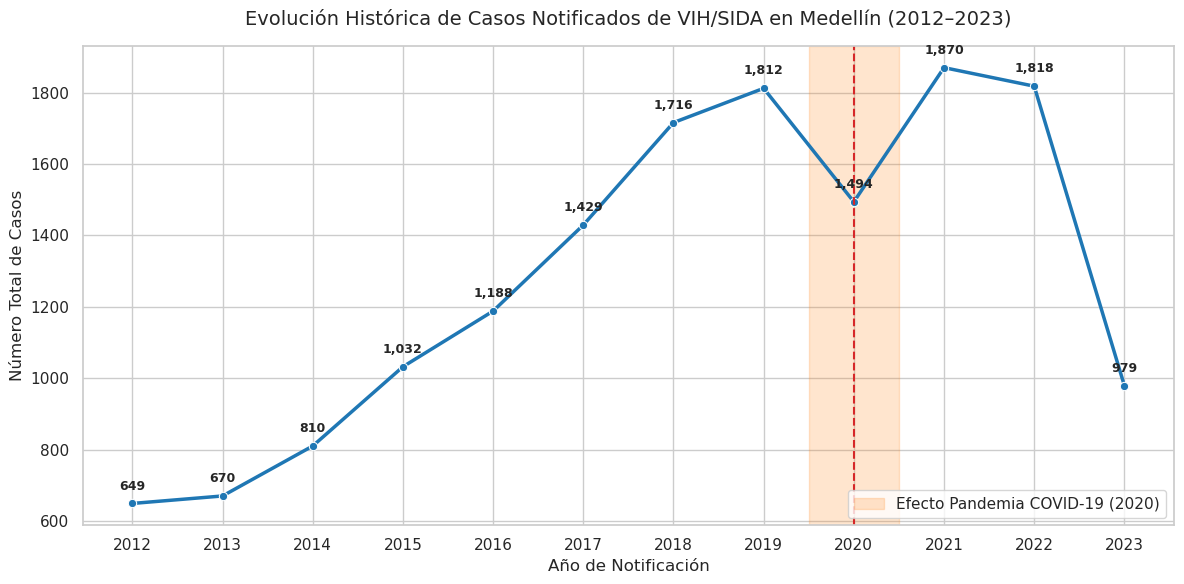

Variaciones porcentuales interanuales:


,Año,Casos_Notificados,Variacion_Pct
0,2012,649,NaN
1,2013,670,3.235747
2,2014,810,20.895522
3,2015,1032,27.407407
4,2016,1188,15.116279
5,2017,1429,20.286195
6,2018,1716,20.083975
7,2019,1812,5.594406
8,2020,1494,-17.549669
9,2021,1870,25.167336


In [14]:
# Agrupación por año
casos_por_anio = df['año'].value_counts().sort_index().reset_index()
casos_por_anio.columns = ['Año', 'Casos_Notificados']
casos_por_anio['Variacion_Pct'] = casos_por_anio['Casos_Notificados'].pct_change() * 100

plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=casos_por_anio, x='Año', y='Casos_Notificados', marker='o', linewidth=2.5, color='#1f77b4')

# Resaltar la caída de la pandemia (2020)
plt.axvspan(2019.5, 2020.5, color='#ff7f0e', alpha=0.2, label='Efecto Pandemia COVID-19 (2020)')
plt.axvline(2020, color='#d62728', linestyle='--', linewidth=1.5)

# Etiquetas de valores
for _, row in casos_por_anio.iterrows():
    ax.annotate(f"{int(row['Casos_Notificados']):,}",
                (row['Año'], row['Casos_Notificados']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontweight='bold', fontsize=9)

plt.title('Evolución Histórica de Casos Notificados de VIH/SIDA en Medellín (2012–2023)', fontsize=14, pad=15)
plt.xlabel('Año de Notificación', fontsize=12)
plt.ylabel('Número Total de Casos', fontsize=12)
plt.xticks(casos_por_anio['Año'])
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# Tabla de variaciones porcentuales
print('Variaciones porcentuales interanuales:')
casos_por_anio


### 7.2 Estacionalidad y Comportamiento por Período Epidemiológico
Analizamos si existen patrones estacionales y concentración mensual de notificaciones a lo largo de los diferentes años mediante un mapa de calor (*heatmap*).


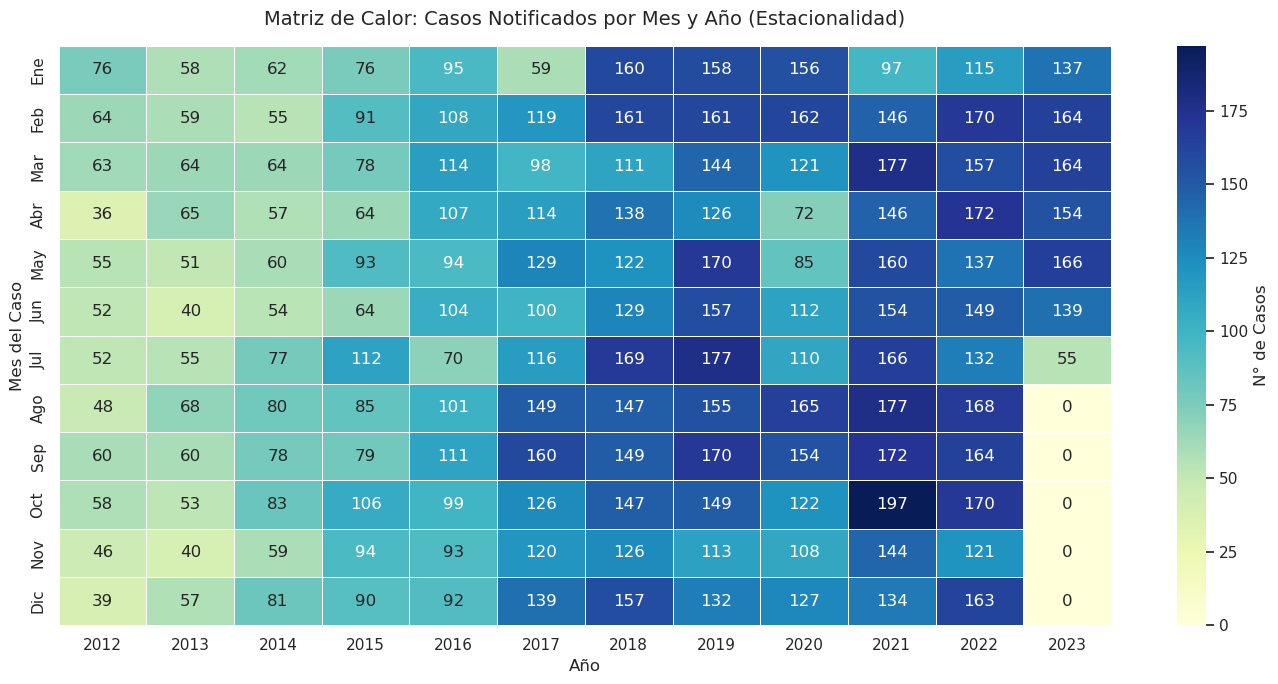

In [15]:
# Tabla cruzada de Año vs Mes
if 'mes_caso' in df.columns:
    matriz_temporal = df.pivot_table(index='mes_caso', columns='año', values='fec_not', aggfunc='count', fill_value=0)
    meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    matriz_temporal.index = [meses_labels[int(m)-1] if str(m).isdigit() and 1 <= int(m) <= 12 else str(m) for m in matriz_temporal.index]

    plt.figure(figsize=(14, 7))
    sns.heatmap(matriz_temporal, cmap='YlGnBu', annot=True, fmt='d', linewidths=0.5, cbar_kws={'label': 'N° de Casos'})
    plt.title('Matriz de Calor: Casos Notificados por Mes y Año (Estacionalidad)', fontsize=14, pad=15)
    plt.xlabel('Año', fontsize=12)
    plt.ylabel('Mes del Caso', fontsize=12)
    plt.tight_layout()
    plt.show()


### 7.3 Retraso Diagnóstico ($\Delta t = \text{Fecha Consulta} - \text{Fecha Inicio Síntomas}$)
El retraso entre el debut de los síntomas y la primera atención médica es un indicador crítico de acceso oportuno al sistema de salud. Evaluamos cómo varió este retraso antes, durante y después de la pandemia.


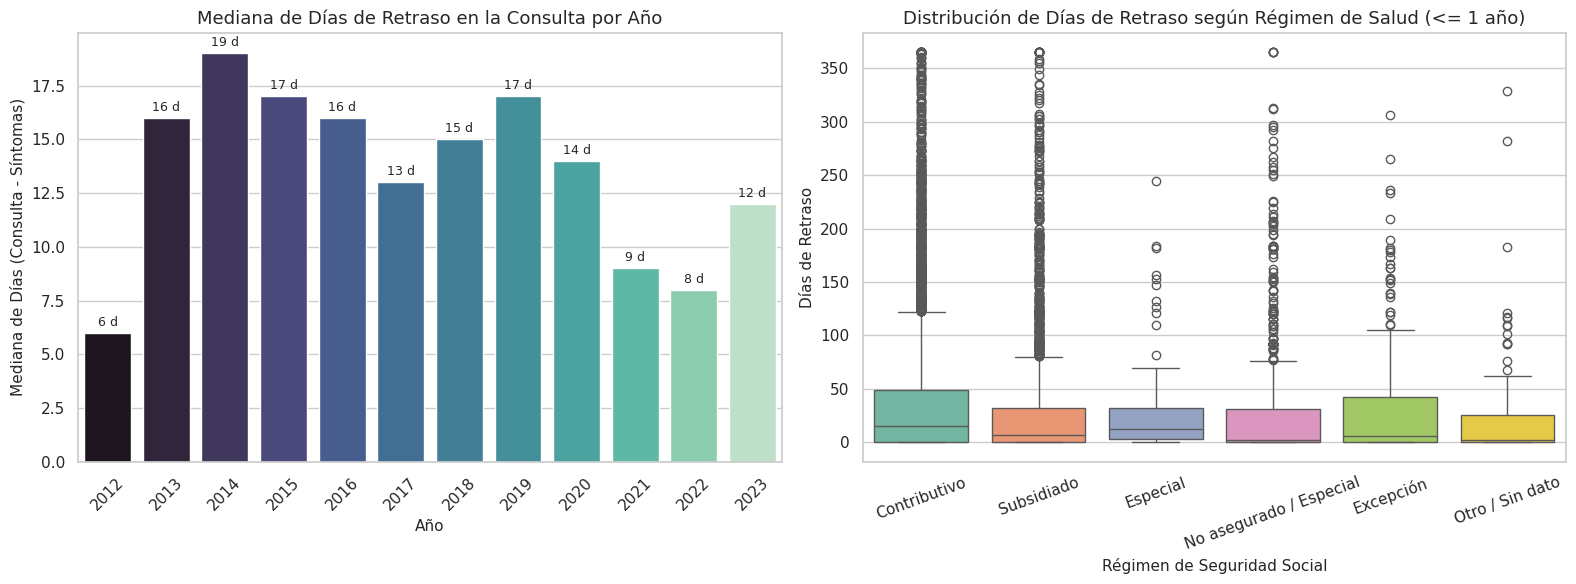

Estadísticos de Retraso Diagnóstico por Año:


,año,Mediana,Media,IQR,N_Casos
0,2012,6.0,53.280467,32.00,599
1,2013,16.0,57.689236,60.00,576
2,2014,19.0,66.294551,61.00,679
3,2015,17.0,72.653571,61.00,840
4,2016,16.0,69.562630,60.00,958
5,2017,13.0,108.553571,49.25,1120
6,2018,15.0,138.799397,61.00,1326
7,2019,17.0,143.791402,68.00,1419
8,2020,14.0,109.397727,61.00,1056
9,2021,9.0,77.053250,46.00,1277


In [16]:
df_retraso = df.dropna(subset=['dias_retraso_diagnostico', 'año']).copy()
df_retraso = df_retraso[df_retraso['dias_retraso_diagnostico'] >= 0]

retraso_anual = df_retraso.groupby('año')['dias_retraso_diagnostico'].agg(
    Mediana='median',
    Media='mean',
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    N_Casos='count'
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Mediana de retraso por año
sns.barplot(data=retraso_anual, x='año', y='Mediana', palette='mako', ax=ax1)
ax1.set_title('Mediana de Días de Retraso en la Consulta por Año', fontsize=13)
ax1.set_xlabel('Año', fontsize=11)
ax1.set_ylabel('Mediana de Días (Consulta - Síntomas)', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.0f} d", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Subplot 2: Distribución de retraso por Régimen de Afiliación
sns.boxplot(data=df_retraso[df_retraso['dias_retraso_diagnostico'] <= 365], 
            x='tip_ss_desc', y='dias_retraso_diagnostico', palette='Set2', ax=ax2)
ax2.set_title('Distribución de Días de Retraso según Régimen de Salud (<= 1 año)', fontsize=13)
ax2.set_xlabel('Régimen de Seguridad Social', fontsize=11)
ax2.set_ylabel('Días de Retraso', fontsize=11)
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('Estadísticos de Retraso Diagnóstico por Año:')
retraso_anual


### 7.4 Dinámica Temporal Desagregada por Sexo y Régimen de Afiliación
Evaluamos si la reducción en las notificaciones durante 2020 afectó de manera desproporcionada a ciertos regímenes o sexos.


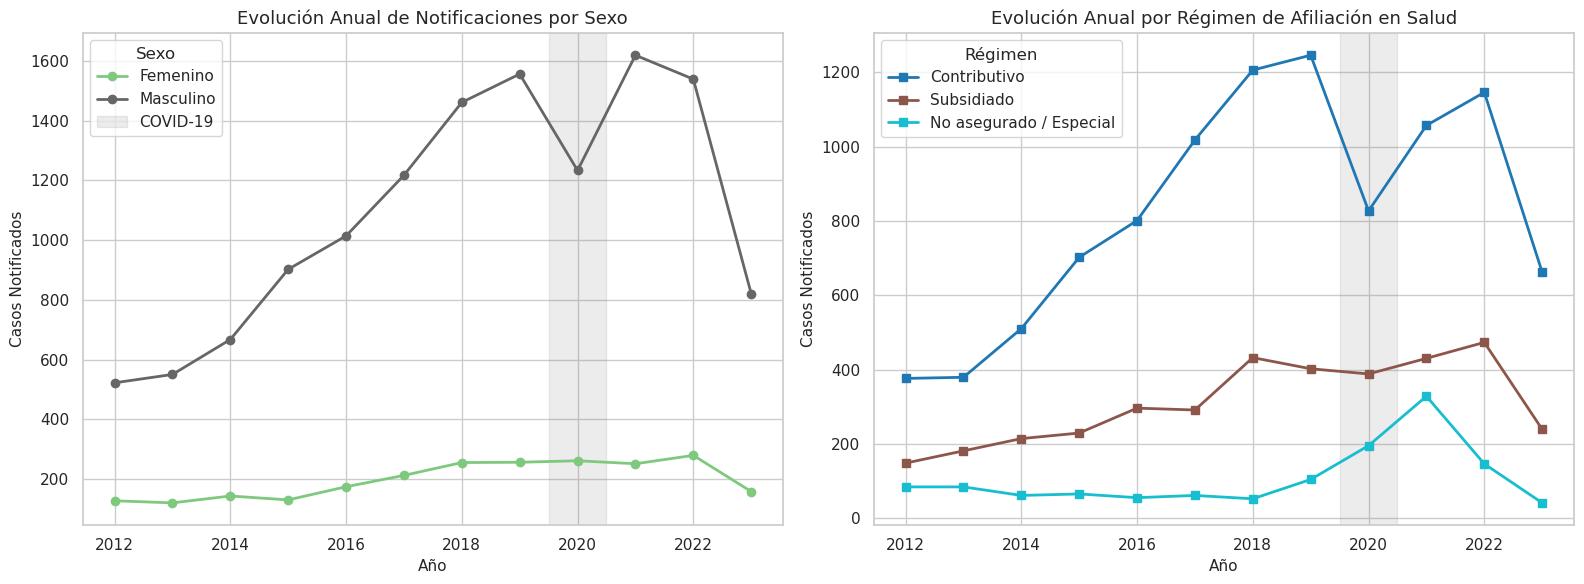

In [17]:
# Notificaciones por Año y Sexo
df_sexo_tiempo = df.groupby(['año', 'sexo_desc']).size().unstack(fill_value=0)

# Notificaciones por Año y Régimen
df_ss_tiempo = df.groupby(['año', 'tip_ss_desc']).size().unstack(fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico por Sexo
df_sexo_tiempo.plot(kind='line', marker='o', ax=ax1, colormap='Accent', linewidth=2)
ax1.set_title('Evolución Anual de Notificaciones por Sexo', fontsize=13)
ax1.set_xlabel('Año', fontsize=11)
ax1.set_ylabel('Casos Notificados', fontsize=11)
ax1.axvspan(2019.5, 2020.5, color='gray', alpha=0.15, label='COVID-19')
ax1.legend(title='Sexo')

# Gráfico por Régimen
regimenes_principales = [c for c in ['Contributivo', 'Subsidiado', 'No asegurado / Especial'] if c in df_ss_tiempo.columns]
df_ss_tiempo[regimenes_principales].plot(
    kind='line', marker='s', ax=ax2, colormap='tab10', linewidth=2
)
ax2.set_title('Evolución Anual por Régimen de Afiliación en Salud', fontsize=13)
ax2.set_xlabel('Año', fontsize=11)
ax2.set_ylabel('Casos Notificados', fontsize=11)
ax2.axvspan(2019.5, 2020.5, color='gray', alpha=0.15)
ax2.legend(title='Régimen')

plt.tight_layout()
plt.show()


## 8. Conclusiones Científicas y Hallazgos Epidemiológicos

1. **Impacto del Choque Sanitario COVID-19 (2020):**
   - Se evidenció una disminución del **17.5%** en las notificaciones de VIH en Medellín durante el año 2020 (1.494 casos frente a 1.812 en 2019). Este fenómeno no representa una reducción biológica de la incidencia, sino un **marcado subregistro y retraso diagnóstico** provocado por los confinamientos obligatorios y la priorización de los servicios de salud en la atención de la emergencia respiratoria.
   - En 2021 y 2022 se observa un efecto de compensación o rebote (alcanzando 1.870 y 1.818 casos anuales), correspondiente a diagnósticos acumulados que no fueron captados oportunamente en 2020.

2. **Dinámica del Retraso Diagnóstico ($\Delta t$):**
   - El tiempo transcurrido entre el inicio de síntomas reportado y la consulta médica evidencia una asimetría positiva pronunciada.
   - La población afiliada al régimen subsidiado y los no asegurados presentan una dispersión mayor en los tiempos de consulta, sugiriendo barreras de acceso en fases tempranas de la infección.

3. **Consistencia Metodológica:**
   - La aplicación de las cuatro etapas del flujo de datos (Lectura controlada, Parseo semántico, Depuración de dominio e Imputación empírica con preservación de varianza) permitió procesar los 15.470 registros de forma reproducible, garantizando la validez estadística de los hallazgos sin introducir sesgos de selección artificiales.
